## SLE - Nahom Gebreyohannis, Niranjana Parashar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import df2img
import pandas as pd 

In [48]:
V1 = 9.71 #V  for the first with red and blue cable
I = 3#A

Vi_l = np.array([128.8, 128.3, 127.8, 127.3, 126.8, 125.8, 123.8, 121.4, 117.3, 111.2, 103.2, 92.4, 79.1, 62.9, 46.0]) #mV
Vi_r = np.array([124.9, 124.5, 124.5, 124.4, 123.7, 122.5, 120.3, 117.1, 112.2, 105.4, 95.5, 83.7, 68.2, 50.8, 34.1])

Uw = 28.5 #V
I_1 = 1.9 #A... for 40mm radius

Uw2 = 24 #V
I_2 = 1.9 #A ... for the second round
Uwa = (Uw + Uw2)/2

R = 0.1475 #m
N = 124
u0 = 1.2566e-6 # (m*kg)/C^2

E = 3.125
r0 = 40e-3 #m
UB = 300 #V

pressure = pd.DataFrame([Vi_l,
                         Vi_r],
                        index=['U in    the -ve z-axis(V)', 'U in    the +ve z-axis(V)'],
                         columns=['0mm', '10mm', '20mm', '30mm', '40mm', '50mm', '60mm', '70mm', '80mm', '90mm', '100mm', '110mm', '120mm', '130mm', '140mm'])
#pressure = pressure.transpose()
dfi = df2img.plot_dataframe(pressure, tbl_header={
        "align": "left",
        "fill_color": "tan",
        "font_color": "black",
        "font_size": 14,
    },
                            tbl_cells={
        "align": "center",
        "fill_color": "oldlace",
        "font_color": "black",
    },
    fig_size=(1000, 200),
    show_fig=False)
dfi.show()
#df2img.save_dataframe(fig=dfi, filename="SlE.png")

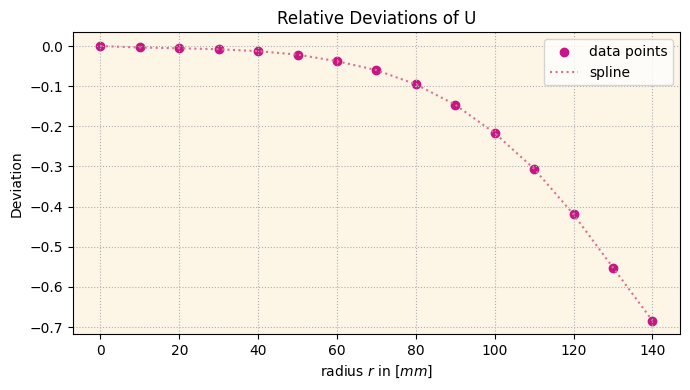

In [52]:
#diagram for all meas
Vi = (Vi_l+Vi_r)/2
dU = (Vi-Vi[0])/Vi[0]
r = np.arange(0,141,10)

#plot
plt.figure(figsize=(7,4))
plt.scatter(r, dU, label='data points', color='mediumvioletred')
plt.plot(r, dU, ':', label='spline', color='palevioletred')
plt.grid(ls=':')
plt.title('Relative Deviations of U')
plt.legend()
plt.xlabel('radius $r$ in $[mm]$')
plt.ylabel('Deviation')
ax = plt.gca()
ax.set_facecolor("oldlace")
plt.tight_layout()
plt.savefig('SLE_ΔV')




pressure = pd.DataFrame([np.round(dU, decimals=4)],
                        index=np.array(['Deviations']),
                         columns=np.array(['0mm', '10mm', '20mm', '30mm', '40mm', '50mm', '60mm', '70mm', '80mm', '90mm', '100mm', '110mm', '120mm', '130mm', '140mm']))
#pressure = pressure.transpose()
#dfi = df2img.plot_dataframe(pressure,  tbl_cells=dict(fill_color='blue'), row_fill_color=("#ffffff", "#d7d8d6"), fig_size=(1200, 1000))
dfi = df2img.plot_dataframe(pressure, tbl_header={
        "align": "left",
        "fill_color": "tan",
        "font_color": "black",
        "font_size": 14,
    },
                            tbl_cells={
        "align": "center",
        "fill_color": "oldlace",
        "font_color": "black",
    },
    fig_size=(1000, 100),
    show_fig=False)
dfi.show()

#df2img.save_dataframe(fig=dfi, filename="SlE.png")

[0.0, -0.0035474970437524857, -0.005518328734726076, -0.007883326763894475, -0.012613322822231049, -0.021284982262514802]


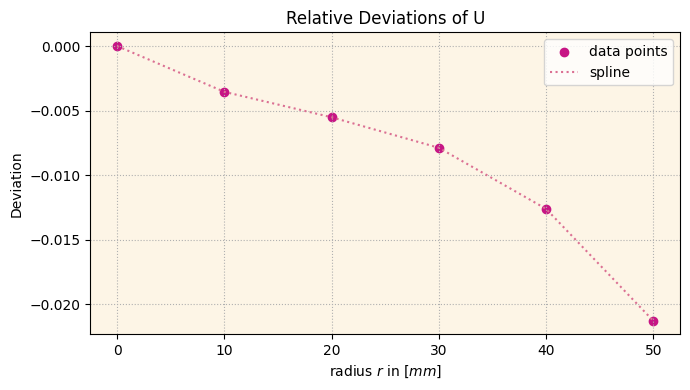

In [53]:
#diagram for up to 50mm
Vi = (Vi_l+Vi_r)/2
dU = (Vi-Vi[0])/Vi[0]
r = np.arange(0,141,10)

dU_50 = dU.tolist()[0:6]
r_50 = r.tolist()[0:6]

#plot
plt.figure(figsize=(7,4))
plt.scatter(r_50, dU_50, label='data points', color='mediumvioletred')
plt.plot(r_50, dU_50, ':', label='spline', color='palevioletred')
plt.grid(ls=':')
plt.title('Relative Deviations of U')
plt.legend()
plt.xlabel('radius $r$ in $[mm]$')
plt.ylabel('Deviation')
ax = plt.gca()
ax.set_facecolor("oldlace")
plt.tight_layout()
#plt.savefig('SLE_ΔV_50')
print(dU_50)

In [54]:
#calculations
C = 0.9874
B = ((I_1 * N * u0 * (4/5)**(3/2))/R)*C
B

#UB = E * B
UB

em = (2*UB)/((B**2)*(r0**2))
em

186472339098.68683

## Error calculation

In [55]:
lt = 1.7588e11
df = ((em - lt)/lt)*100
df

6.022480724748027

In [56]:
dfU = (0.005*300)+0.3
dfI = (0.02*1.9)+0.05
dfR = 0.5e-3
dfr = 4e-3
dC = 0.3
dfU1 = (0.005*(((128.8+124.9)/2)*10**(-3)))+dC
dfU2 = (0.005*(((126.8+123.7)/2)*10**(-3)))+dC
print(dfU1, dfU2)
dfoU = np.sqrt(((dfU1*((126.8+123.7)/2))/(((128.8+124.9)/2)**2))**2 + (dfU2/((128.8+124.9)/2)**2))
dfB = np.sqrt((C*(4/5)**(3/2)*((N*u0)/(r0))*dfI)**2 + (C*(4/5)**(3/2)*((I_1*N*u0)/(r0**2))*dfr)**2 + ((dfoU*(4/5)**(3/2)*I_1*N*u0)/(r0))**2)
dfem = np.sqrt(((dfU*2)/((B**2)*(r0**2)))**2 + ((dfr*4*UB)/((B**2)*(r0**3)))**2 + ((dfB*4*UB)/((B**3)*(r0**2)))**2)
print(dfB, dfem)
print(dfoU, dfI)
print(dfem/(10**11))

0.30063425 0.30062625
0.00057687873208829 156232909393.80038
0.004915186740230716 0.088
1.562329093938004
